In [1]:
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
random.seed(41)
torch.manual_seed(41)

In [2]:
x = torch.rand(4,3)
x

tensor([[0.2364, 0.2266, 0.8005],
        [0.1692, 0.2650, 0.7720],
        [0.1282, 0.7452, 0.8045],
        [0.6357, 0.5896, 0.6933]])

In [3]:
x_transpose = torch.transpose(x,dim0 =1 ,dim1=-2)
x_transpose

tensor([[0.2364, 0.1692, 0.1282, 0.6357],
        [0.2266, 0.2650, 0.7452, 0.5896],
        [0.8005, 0.7720, 0.8045, 0.6933]])

In [4]:
x_transpose.reshape(4,3)

tensor([[0.2364, 0.1692, 0.1282],
        [0.6357, 0.2266, 0.2650],
        [0.7452, 0.5896, 0.8005],
        [0.7720, 0.8045, 0.6933]])

In [5]:
x[:,1:]

tensor([[0.2266, 0.8005],
        [0.2650, 0.7720],
        [0.7452, 0.8045],
        [0.5896, 0.6933]])

In [6]:
torch.add(x,x_transpose.t())

tensor([[0.4729, 0.4532, 1.6011],
        [0.3384, 0.5299, 1.5440],
        [0.2564, 1.4904, 1.6089],
        [1.2714, 1.1792, 1.3866]])

In [7]:
torch.sub(x,x_transpose.t())

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [8]:
torch.mul(x,x_transpose)

RuntimeError: The size of tensor a (3) must match the size of tensor b (4) at non-singleton dimension 1

In [9]:
x.shape

torch.Size([4, 3])

In [10]:
x_transpose.shape

torch.Size([3, 4])

In [11]:
torch.matmul(x,x_transpose)

tensor([[0.7481, 0.7181, 0.8432, 0.8389],
        [0.7181, 0.6948, 0.8402, 0.7990],
        [0.8432, 0.8402, 1.2189, 1.0786],
        [0.8389, 0.7990, 1.0786, 1.2324]])

In [12]:
torch.div(x,x)

tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])

In [13]:
torch.remainder(x,x)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [14]:
torch.pow(x,x)

tensor([[0.7111, 0.7143, 0.8369],
        [0.7404, 0.7033, 0.8189],
        [0.7685, 0.8032, 0.8394],
        [0.7498, 0.7324, 0.7757]])

In [15]:
x.add(x), x.sub(x), x.mul(x), x.matmul(x_transpose), x.div(x), x.remainder(x), x.pow(x)

(tensor([[0.4729, 0.4532, 1.6011],
         [0.3384, 0.5299, 1.5440],
         [0.2564, 1.4904, 1.6089],
         [1.2714, 1.1792, 1.3866]]),
 tensor([[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]),
 tensor([[0.0559, 0.0514, 0.6408],
         [0.0286, 0.0702, 0.5960],
         [0.0164, 0.5553, 0.6472],
         [0.4041, 0.3476, 0.4807]]),
 tensor([[0.7481, 0.7181, 0.8432, 0.8389],
         [0.7181, 0.6948, 0.8402, 0.7990],
         [0.8432, 0.8402, 1.2189, 1.0786],
         [0.8389, 0.7990, 1.0786, 1.2324]]),
 tensor([[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]),
 tensor([[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]),
 tensor([[0.7111, 0.7143, 0.8369],
         [0.7404, 0.7033, 0.8189],
         [0.7685, 0.8032, 0.8394],
         [0.7498, 0.7324, 0.7757]]))

In [16]:
## reassignment var.fun_(var)
x.pow_(x)

tensor([[0.7111, 0.7143, 0.8369],
        [0.7404, 0.7033, 0.8189],
        [0.7685, 0.8032, 0.8394],
        [0.7498, 0.7324, 0.7757]])

In [17]:
x

tensor([[0.7111, 0.7143, 0.8369],
        [0.7404, 0.7033, 0.8189],
        [0.7685, 0.8032, 0.8394],
        [0.7498, 0.7324, 0.7757]])

In [77]:
class Model(nn.Module):
    def __init__(self,n_input = 4, h1=8, h2=9, n_output=3):
        super().__init__()
        self.fc1 = nn.Linear(n_input, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2,n_output)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [78]:
model = Model()

In [79]:
iris_url = "https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"
df = pd.read_csv(iris_url)

In [80]:
df.head(-5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
140,6.7,3.1,5.6,2.4,virginica
141,6.9,3.1,5.1,2.3,virginica
142,5.8,2.7,5.1,1.9,virginica
143,6.8,3.2,5.9,2.3,virginica


In [81]:
df.info(),df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


(None,
        sepal_length  sepal_width  petal_length  petal_width
 count    150.000000   150.000000    150.000000   150.000000
 mean       5.843333     3.054000      3.758667     1.198667
 std        0.828066     0.433594      1.764420     0.763161
 min        4.300000     2.000000      1.000000     0.100000
 25%        5.100000     2.800000      1.600000     0.300000
 50%        5.800000     3.000000      4.350000     1.300000
 75%        6.400000     3.300000      5.100000     1.800000
 max        7.900000     4.400000      6.900000     2.500000)

In [82]:
lb = LabelEncoder()
df['species'] = lb.fit_transform(df['species'])

In [83]:
X_train.shape

torch.Size([120, 4])

In [84]:
X_train, X_test,y_train, y_test = train_test_split(df.iloc[:,0:4],df.iloc[:,4] ,random_state=41, test_size=0.2,shuffle=True)
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)
y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

In [85]:
criterion = nn.CrossEntropyLoss()

In [98]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [99]:
epochs = 100
losses = []
for i in range(epochs):
    y_pred = model.forward(X_train)
    loss = criterion(y_pred,y_train)
    losses.append(loss.detach().numpy())
    if i % 10 == 0:
        print(f"iteration : {i} and loss : {loss}")
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

iteration : 0 and loss : 0.09678361564874649
iteration : 10 and loss : 0.0722011849284172
iteration : 20 and loss : 0.05684901401400566
iteration : 30 and loss : 0.0494411326944828
iteration : 40 and loss : 0.04429157078266144
iteration : 50 and loss : 0.03999606892466545
iteration : 60 and loss : 0.036657799035310745
iteration : 70 and loss : 0.03397371992468834
iteration : 80 and loss : 0.03168318793177605
iteration : 90 and loss : 0.029681025072932243


<function matplotlib.pyplot.show(close=None, block=None)>

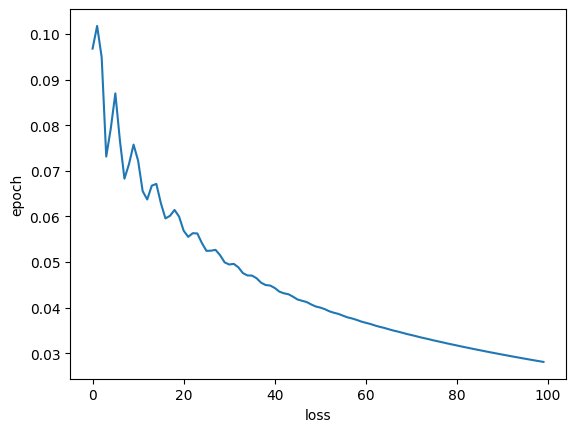

In [100]:
plt.plot(range(epochs),losses)
plt.xlabel("loss")
plt.ylabel("epoch")
plt.show

In [101]:
with torch.no_grad():
    y_eval = model.forward(X_test)
    loss = criterion(y_eval,y_test)
loss

tensor(0.1493)

In [102]:
new_iris = torch.tensor([5.9,3.0,5.1,1.8])

In [103]:
with torch.no_grad():
    print(model(new_iris))

tensor([-17.8242,   0.3126,   4.4121])
